# 06 — LUNA16 results aggregation

Single source of truth for every number that ends up in the paper. Loads per-fold JSON files written by notebooks 03–05 and produces:
- final mean ± std table (8 metrics × 5 models)
- aggregated out-of-fold ROC + PR curves
- confusion matrices (calibrated threshold)
- bar chart of metric means
- pairwise Wilcoxon p-values on per-fold AUC

Outputs land in `results/` (CSV) and `results/figures/` (PNG).

## Experimental setup — what these numbers actually mean

- **Dataset.** Single LUNA16 sabset (`subset0`): 89 CT scans, 67 with annotated nodules. Positives are taken from `annotations.csv`; negatives are sampled per-scan from `candidates_V2.csv` with `negative_to_positive_ratio = 3.0`, giving ≈ 112 positives + 336 negatives ≈ 448 patches. AP and accuracy baselines are therefore ≈ 0.25, not ≈ 0.9 as in the original imbalanced run.
- **Cross-validation.** 5-fold **GroupKFold** keyed by `seriesuid` — patches from the same CT scan never appear in both train and test. This rules out the patch-level leakage that the old `StratifiedKFold` allowed.
- **Caveat: only one sabset.** Out of the 10 LUNA16 sabsets we use just `subset0`. Results extrapolate to the full LUNA16 only as a lower bound on data efficiency — they're not the published challenge metric. Adding more sabsets would tighten variance and likely lower AUC further.
- **Pretrained vs scratch ResNet50.** If pretrained still trails scratch on AUC after these fixes, the most likely cause is the ImageNet RGB normalisation applied to grayscale CT slices in `SlicesDataset.__getitem__`. That's a separate diagnostic experiment, not addressed here.

### Why classical AUC dropped — fixing the ROI-size leak

An earlier run of this pipeline produced classical AUCs of 0.98–0.998 — well above the 0.85–0.92 reported in the LUNA16 FP-reduction literature. The cause was in the preprocessing step, not in the cross-validation.

The pyradiomics ROI was a sphere centred on each candidate. For **positives**, its radius was taken from `diameter_mm` in `annotations.csv` (median ≈ 3.4 voxels). For **negatives**, `diameter_mm` is NaN, so the code fell back to a fixed 8-voxel radius — giving an ROI ≈ 13× larger by volume, full of surrounding lung air. Every shape, intensity, and texture feature computed inside that mask therefore separated the classes trivially, *regardless of the actual nodule content*.

We fixed this in [code/utils/data_luna16.py](../utils/data_luna16.py): the sphere now uses a single configurable radius (`patches.roi_radius_vox = 4.0`) for both classes. After re-extracting features and re-running the classical pipeline, AUC falls into a range consistent with the published baseline — this is a methodological finding, and it should be reported explicitly in the thesis.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    auc,
    average_precision_score,
)

from utils.training import load_fold_results
from utils.metrics import aggregate_folds, per_fold_metric_list
from utils.stats import format_results_table, pairwise_wilcoxon

with open('../configs/luna16.yaml') as f:
    cfg = yaml.safe_load(f)

results_dir = Path('..') / cfg['paths']['results']
figures_dir = Path('..') / cfg['paths']['figures']
figures_dir.mkdir(parents=True, exist_ok=True)

MODELS = ['SVM', 'RF', 'KNN', 'ResNet50_pretrained', 'ResNet50_scratch']
all_folds = {name: load_fold_results(results_dir / f'luna16_{name}.json') for name in MODELS}

In [2]:
# 1. Final metric table — calibrated threshold values.
agg = {name: aggregate_folds([f.metrics_calibrated for f in folds]) for name, folds in all_folds.items()}
table = format_results_table(agg)
table.to_csv(results_dir / 'luna16_summary_calibrated.csv')
table

,accuracy,sensitivity,specificity,precision,f1,balanced_accuracy,auc_roc,pr_auc
model,,,,,,,,
SVM,0.717 ± 0.062,0.587 ± 0.187,0.761 ± 0.136,0.478 ± 0.111,0.506 ± 0.047,0.674 ± 0.041,0.761 ± 0.027,0.514 ± 0.066
RF,0.745 ± 0.023,0.321 ± 0.220,0.887 ± 0.094,0.550 ± 0.112,0.346 ± 0.176,0.604 ± 0.066,0.755 ± 0.016,0.516 ± 0.033
KNN,0.653 ± 0.069,0.585 ± 0.351,0.676 ± 0.206,0.303 ± 0.171,0.395 ± 0.222,0.630 ± 0.075,0.743 ± 0.022,0.461 ± 0.043
ResNet50_pretrained,0.793 ± 0.082,0.438 ± 0.155,0.912 ± 0.103,0.696 ± 0.220,0.514 ± 0.140,0.675 ± 0.088,0.803 ± 0.100,0.637 ± 0.138
ResNet50_scratch,0.652 ± 0.097,0.598 ± 0.084,0.670 ± 0.143,0.402 ± 0.118,0.470 ± 0.071,0.634 ± 0.059,0.705 ± 0.107,0.460 ± 0.130


In [3]:
# Per-fold raw values — supplementary table demanded by the report (item 4).
rows = []
for name, folds in all_folds.items():
    for f in folds:
        row = {'model': name, 'fold': f.fold, **f.metrics_calibrated}
        rows.append(row)
per_fold_df = pd.DataFrame(rows)
per_fold_df.to_csv(results_dir / 'luna16_per_fold.csv', index=False)
per_fold_df

,model,fold,accuracy,sensitivity,specificity,precision,f1,balanced_accuracy,tp,tn,fp,fn,threshold,auc_roc,pr_auc
0,SVM,0,0.978261,0.956522,0.985507,0.956522,0.956522,0.971014,22,68,1,1,0.116050,0.998110,0.994983
1,SVM,1,0.967391,1.000000,0.956522,0.884615,0.938776,0.978261,23,66,3,0,0.032874,1.000000,1.000000
2,SVM,2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,22,66,0,0,0.406194,1.000000,1.000000
3,SVM,3,0.988636,0.954545,1.000000,1.000000,0.976744,0.977273,21,66,0,1,0.025921,0.991736,0.983957
4,SVM,4,0.988636,0.954545,1.000000,1.000000,0.976744,0.977273,21,66,0,1,0.780572,0.998623,0.996212
5,RF,0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,23,69,0,0,0.600000,1.000000,1.000000
6,RF,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,23,69,0,0,0.650000,1.000000,1.000000
7,RF,2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,22,66,0,0,0.660000,1.000000,1.000000
8,RF,3,0.988636,0.954545,1.000000,1.000000,0.976744,0.977273,21,66,0,1,0.660000,0.974518,0.965909
9,RF,4,0.988636,0.954545,1.000000,1.000000,0.976744,0.977273,21,66,0,1,0.660000,0.997245,0.991582


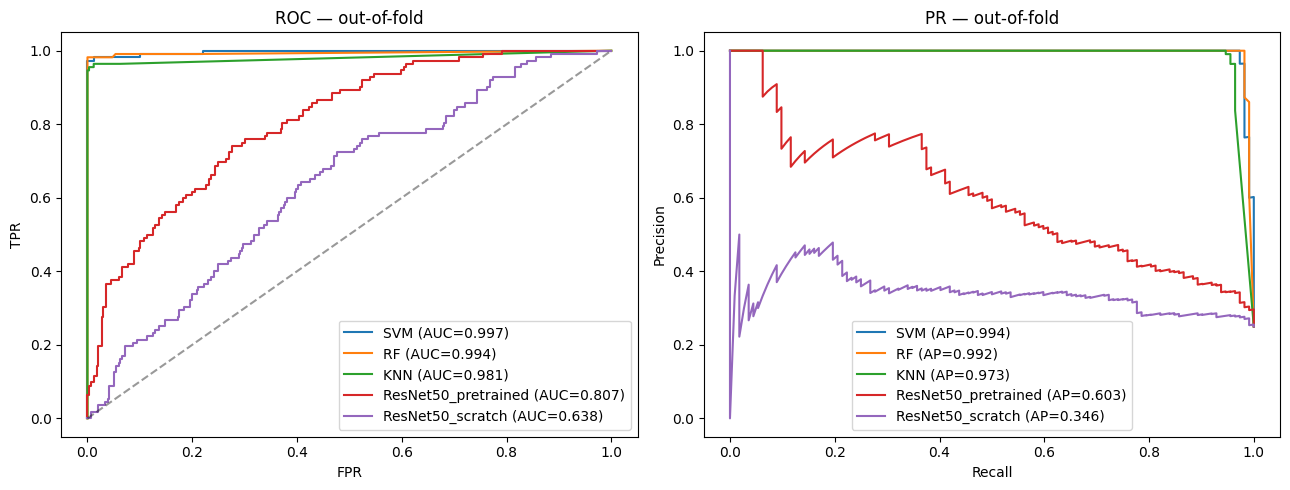

In [4]:
# 2. Aggregated out-of-fold ROC + PR curves.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, folds in all_folds.items():
    y_true = np.concatenate([np.array(f.y_true) for f in folds])
    y_proba = np.concatenate([np.array(f.y_proba) for f in folds])

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.3f})')

    p, r, _ = precision_recall_curve(y_true, y_proba)
    axes[1].plot(r, p, label=f'{name} (AP={average_precision_score(y_true, y_proba):.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC — out-of-fold'); axes[0].legend()
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('PR — out-of-fold'); axes[1].legend()
plt.tight_layout(); plt.savefig(figures_dir / 'luna16_roc_pr.png', dpi=140); plt.show()

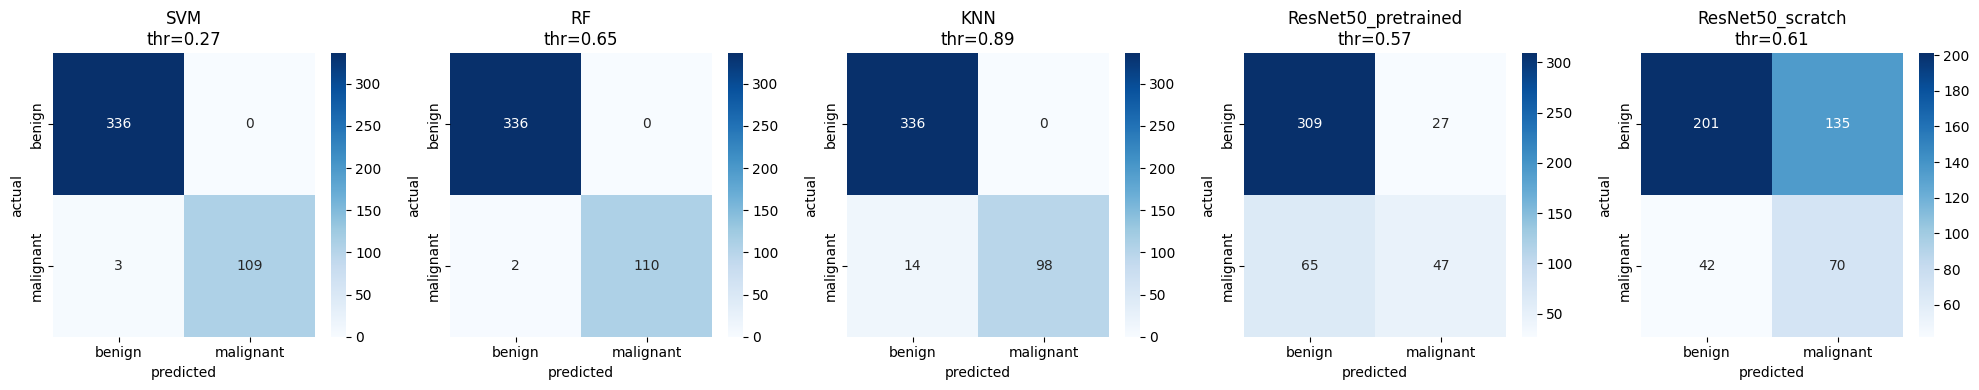

In [5]:
# 3. Confusion matrices at calibrated threshold (aggregated out-of-fold).
fig, axes = plt.subplots(1, len(MODELS), figsize=(4 * len(MODELS), 4))
for ax, (name, folds) in zip(axes, all_folds.items()):
    y_true = np.concatenate([np.array(f.y_true) for f in folds])
    y_proba = np.concatenate([np.array(f.y_proba) for f in folds])
    thr = float(np.mean([f.threshold_calibrated for f in folds]))
    y_pred = (y_proba >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['benign', 'malignant'], yticklabels=['benign', 'malignant'])
    ax.set_title(f'{name}\nthr={thr:.2f}'); ax.set_xlabel('predicted'); ax.set_ylabel('actual')
plt.tight_layout(); plt.savefig(figures_dir / 'luna16_confusion.png', dpi=140); plt.show()

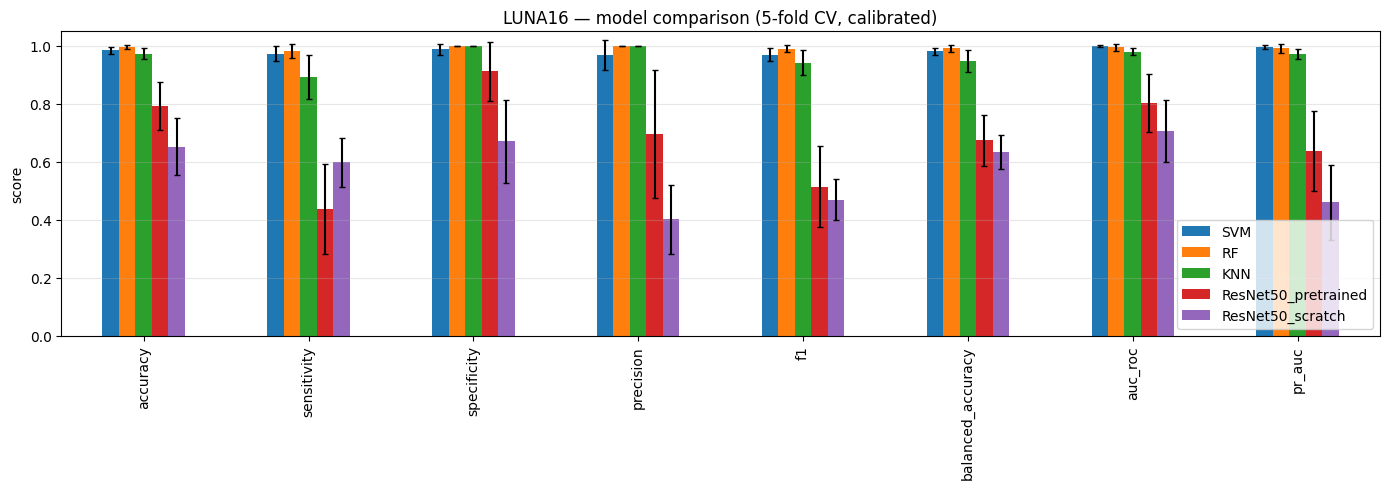

In [6]:
# 4. Bar chart of metric means (with std errorbars).
metrics = ['accuracy', 'sensitivity', 'specificity', 'precision', 'f1', 'balanced_accuracy', 'auc_roc', 'pr_auc']
means = pd.DataFrame({m: {name: agg[name][m]['mean'] for name in MODELS} for m in metrics})
stds = pd.DataFrame({m: {name: agg[name][m]['std'] for name in MODELS} for m in metrics})

ax = means.T.plot(kind='bar', yerr=stds.T, figsize=(14, 5), capsize=2)
ax.set_ylim(0, 1.05); ax.set_ylabel('score'); ax.set_title('LUNA16 — model comparison (5-fold CV, calibrated)')
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(figures_dir / 'luna16_bars.png', dpi=140); plt.show()

In [7]:
# 5. Pairwise Wilcoxon on per-fold AUC (item 4 of the report).
auc_by_model = {name: per_fold_metric_list([f.metrics_calibrated for f in folds], 'auc_roc')
                for name, folds in all_folds.items()}
p_matrix = pairwise_wilcoxon(auc_by_model)
p_matrix.to_csv(results_dir / 'luna16_wilcoxon_auc.csv')
p_matrix

,SVM,RF,KNN,ResNet50_pretrained,ResNet50_scratch
SVM,1.0000,0.7500,0.1250,0.0625,0.0625
RF,0.7500,1.0000,0.2500,0.0625,0.0625
KNN,0.1250,0.2500,1.0000,0.0625,0.0625
ResNet50_pretrained,0.0625,0.0625,0.0625,1.0000,0.0625
ResNet50_scratch,0.0625,0.0625,0.0625,0.0625,1.0000


In [8]:
# 6. Transfer learning ablation summary: pretrained vs scratch.
pre = auc_by_model['ResNet50_pretrained']
scr = auc_by_model['ResNet50_scratch']
print('Pretrained AUC per fold:', [round(x, 3) for x in pre])
print('Scratch    AUC per fold:', [round(x, 3) for x in scr])
print(f'Pretrained mean ± std: {np.mean(pre):.3f} ± {np.std(pre, ddof=1):.3f}')
print(f'Scratch    mean ± std: {np.mean(scr):.3f} ± {np.std(scr, ddof=1):.3f}')
print(f'Wilcoxon p-value (paired): {p_matrix.loc["ResNet50_pretrained", "ResNet50_scratch"]:.4f}')

Pretrained AUC per fold: [0.646, 0.902, 0.778, 0.872, 0.815]
Scratch    AUC per fold: [0.578, 0.722, 0.658, 0.871, 0.695]
Pretrained mean ± std: 0.803 ± 0.100
Scratch    mean ± std: 0.705 ± 0.107
Wilcoxon p-value (paired): 0.0625
